# Daily Challenge: Exploring the World Happiness Report with Matplotlib

In [1]:
import pandas as pd

df = pd.read_csv('data/2019.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Shape: (156, 9)

Columns: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

First 5 rows:


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [2]:
# Check missing values
print('Missing values per column:')
print(df.isnull().sum())

# Drop rows with missing values (if any)
df = df.dropna()

# Check data types
print('\nData types:')
print(df.dtypes)

# Rename columns for easier access (strip spaces)
df.columns = df.columns.str.strip()

print('\nCleaned dataset shape:', df.shape)

Missing values per column:
Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64

Data types:
Overall rank                      int64
Country or region                object
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object

Cleaned dataset shape: (156, 9)


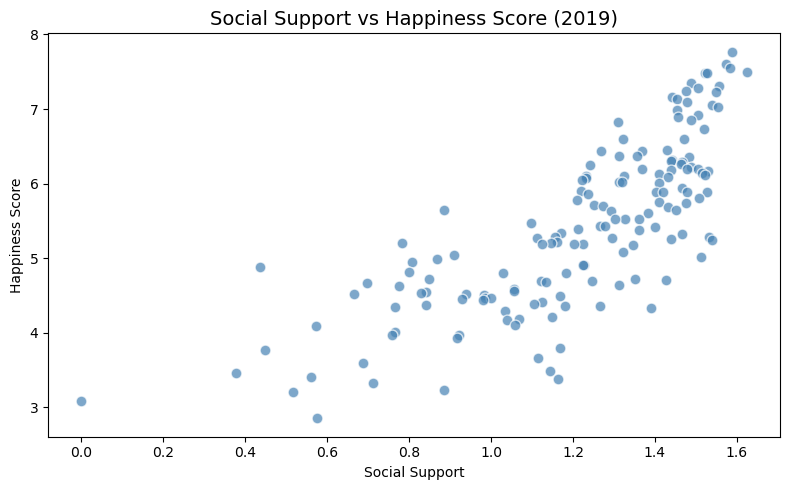

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(df['Social support'], df['Score'], color='steelblue', alpha=0.7, edgecolors='white', s=60)

plt.title('Social Support vs Happiness Score (2019)', fontsize=14)
plt.xlabel('Social Support')
plt.ylabel('Happiness Score')
plt.tight_layout()
plt.show()

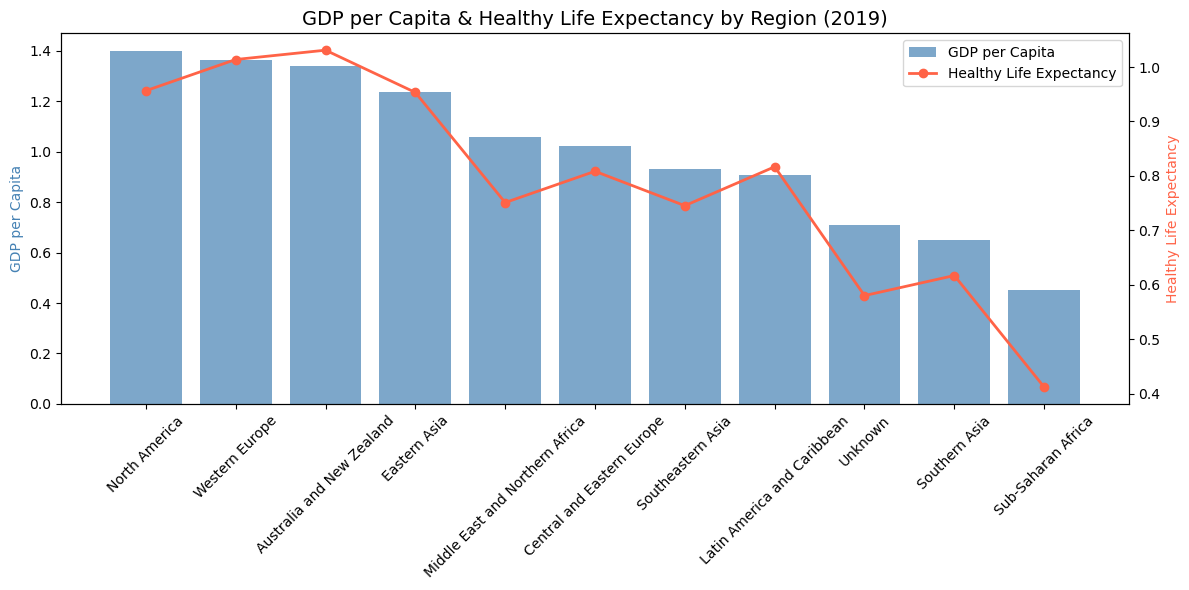

In [5]:
# Load 2019 file which has no Region column — use 2015 to map countries to regions
df_2015 = pd.read_csv('data/2015.csv')[['Country', 'Region']]
df = df.merge(df_2015, left_on='Country or region', right_on='Country', how='left')
df['Region'] = df['Region'].fillna('Unknown')

# Aggregate by region
regional = df.groupby('Region')[['GDP per capita', 'Healthy life expectancy']].mean().sort_values('GDP per capita', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

# Bar plot — GDP per Capita
bars = ax.bar(regional.index, regional['GDP per capita'], color='steelblue', alpha=0.7, label='GDP per Capita')
ax.set_ylabel('GDP per Capita', color='steelblue')
ax.tick_params(axis='x', rotation=45)

# Line plot — Healthy Life Expectancy on secondary axis
ax2 = ax.twinx()
ax2.plot(regional.index, regional['Healthy life expectancy'], color='tomato', marker='o', linewidth=2, label='Healthy Life Expectancy')
ax2.set_ylabel('Healthy Life Expectancy', color='tomato')

# Legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('GDP per Capita & Healthy Life Expectancy by Region (2019)', fontsize=14)
plt.tight_layout()
plt.show()